In [1]:
# how to uncover truths that don't matter - third section

In [2]:
import numpy as np

import matplotlib.pyplot as plt 
import seaborn as sns

import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors

import coriolis_functions
import coriolis_module

In [3]:
fdf = pd.read_csv("data/coriolis_flights_3m.csv", sep=";").astype(
    {
        "FL_DATE": "datetime64[ns]", 
        "AIRLINE": "category", 
        "AIRLINE_DOT": "category", 
        "AIRLINE_CODE": "category", 
        "ORIGIN": "category", 
        "ORIGIN_CITY": "category", 
        "DEST": "category",
        "DEST_CITY": "category", 
        "CANCELLED": "bool",
        "CANCELLATION_CODE": "category", 
        "DIVERTED": "bool",
    }
)

In [4]:
ldf = pd.read_csv("data/airports.csv").astype(
    {
        "IATA": "category",
        "AIRPORT": "category",
        "CITY": "category",
        "STATE": "category",
        "COUNTRY": "category",
    }
)

In [5]:
# checking unique values in both datasets
fdf_airports = set(fdf["ORIGIN"].unique()).union(set(fdf["DEST"].unique()))
ldf_airports = set(ldf["IATA"].unique())  

# finding missing airport codes in ldf
missing_airports = fdf_airports.difference(ldf_airports)

# dropping rows where "ORIGIN" or "DEST" are in missing_airports
fdf = fdf[~fdf["ORIGIN"].isin(missing_airports) & ~fdf["DEST"].isin(missing_airports)]

# merging fdf with ldf to add geographical data for ORIGIN and DEST
fdf = pd.merge(fdf, ldf[["IATA", "LATITUDE", "LONGITUDE"]], 
                      left_on="ORIGIN", right_on="IATA", how="left")

fdf = pd.merge(fdf, ldf[["IATA", "LATITUDE", "LONGITUDE"]], 
                      left_on="DEST", right_on="IATA", how="left", suffixes=("_ORIGIN", "_DEST"))

# dropping original origin and destination columns
fdf = fdf.drop(["ORIGIN", "DEST"], axis=1)

# enforcing categories on newly generated columns
fdf[["IATA_ORIGIN", "IATA_DEST"]] = fdf[["IATA_ORIGIN", "IATA_DEST"]].astype("category")

In [6]:
# calculating haversinedistance
fdf["haversine_distance"] = coriolis_functions.haversine(
    fdf["LATITUDE_ORIGIN"],
    fdf["LONGITUDE_ORIGIN"],
    fdf["LATITUDE_DEST"], 
    fdf["LONGITUDE_DEST"]
)

In [7]:
# printing number of before rows 
print("number of rows before cleaning: ", rows_before_cleaning := len(fdf))
# clean up for other model
fdf.dropna(subset=["total_drift_distance", "haversine_distance"], inplace=True)
# printing number of rows after cleaning
print("number of rows after cleaning: ", len(fdf))
print("number of rows lost due cleaning: ", rows_before_cleaning - len(fdf))

number of rows before cleaning:  2948087
number of rows after cleaning:  2730145
number of rows lost due cleaning:  217942


In [8]:
data = fdf[["haversine_distance", "total_drift_distance"]].to_numpy()

In [9]:
# configuring DBSCAN parameters
dbscan = DBSCAN(eps=0.5, min_samples=10) 

In [10]:
clusters = dbscan.fit_predict(data)

In [11]:
fdf["cluster"] = clusters

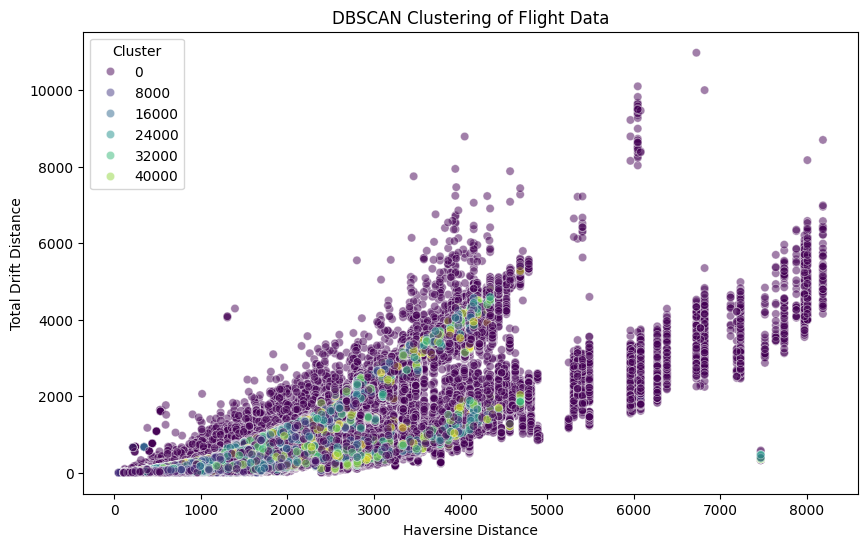

In [14]:
plt.figure(figsize=(10, 6))

sns.scatterplot(x="haversine_distance", y="total_drift_distance", data=fdf, hue="cluster", palette="viridis", alpha=0.5)

# Add labels and title if you want
plt.xlabel("Haversine Distance")
plt.ylabel("Total Drift Distance")
plt.title("DBSCAN Clustering of Flight Data")
plt.legend(loc="upper left", title="Cluster")
plt.show()

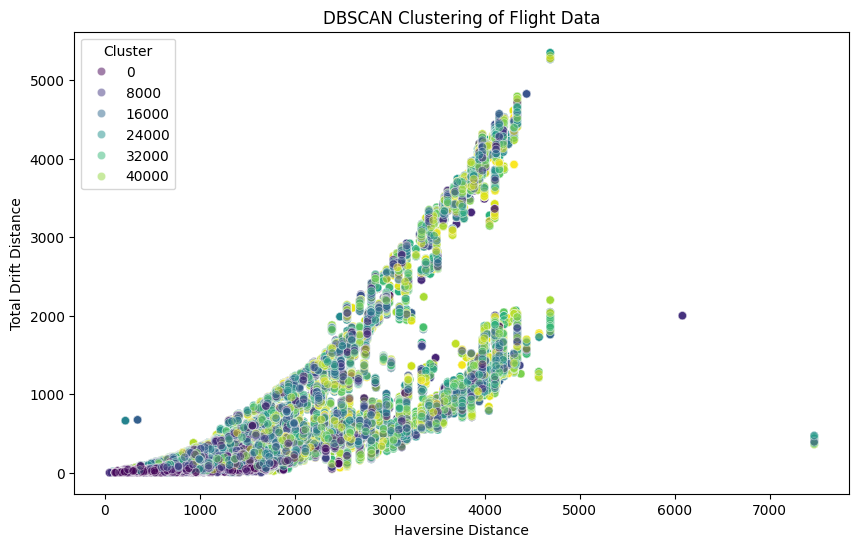

In [15]:
plt.figure(figsize=(10, 6))

sns.scatterplot(x="haversine_distance", y="total_drift_distance", data=fdf[fdf["cluster"] != -1], hue="cluster", palette="viridis", alpha=0.5)

# Add labels and title if you want
plt.xlabel("Haversine Distance")
plt.ylabel("Total Drift Distance")
plt.title("DBSCAN Clustering of Flight Data")
plt.legend(loc="upper left", title="Cluster")
plt.show()